In [2]:
import math
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

In [3]:
class RNNScratch(d2l.Module):  #@save
    """The RNN model implemented from scratch."""
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W_xh = nn.Parameter(
            torch.randn(num_inputs, num_hiddens) * sigma)
        self.W_hh = nn.Parameter(
            torch.randn(num_hiddens, num_hiddens) * sigma)
        self.b_h = nn.Parameter(torch.zeros(num_hiddens))

    def forward(self, inputs, state=None):
        if state is None:
            # Initial state with shape: (batch_size, num_hiddens)
            state = torch.zeros((inputs.shape[1], self.num_hiddens),
                            device=inputs.device)
        else:
            state, = state
        outputs = []
        for X in inputs:  # Shape of inputs: (num_steps, batch_size, num_inputs)
            state = torch.tanh(torch.matmul(X, self.W_xh) +
                            torch.matmul(state, self.W_hh) + self.b_h)
            outputs.append(state)
        return outputs, state

In [4]:
batch_size, num_inputs, num_hiddens, num_steps = 2, 16, 32, 100
rnn = RNNScratch(num_inputs, num_hiddens)
X = torch.ones((num_steps, batch_size, num_inputs))
outputs, state = rnn(X)

In [ ]:
# model.predict('it has', 20, data.vocab, d2l.try_gpu()) 

NameError: name 'model' is not defined

In [6]:
class RNNfromScratch(nn.Module):
    def __init__(self, rnn, vocab_size, lr=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.init_params()

    def init_params(self):
        self.W_hq = nn.Parameter(torch.randn(self.rnn.hidden_size, self.vocab_size) * self.rnn.sigma)
        self.b_q = nn.Parameter(torch.zeros(self.vocab_size))

    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('ppl', torch.exp(1), train=True)
        return l
    
    def validation_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('ppl', torch.exp(1), train=False)

    def one_hot(self, X):
        return F.one_hot(X.T, self.vocab_size).type(torch.float32)
    
    def forward(self, X, state=None):
        embs = self.one_hot(X)
        rnn_outputs, _ = self.rnn(embs, state)
        return self.output_layer(rnn_outputs)
        
    def output_layer(self, rnn_outputs):
        outputs = [torch.matmul(H, self.W_hq) + self.b_q for H in rnn_outputs]
        return torch.stack(outputs, 1)

    def clip_gradients(self, grad_clip_val, model):
        params = [p for p in model.parameters() if p.requires_grad]
        norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
        if norm > grad_clip_val:
            for param in params:
                param.grad[:] *= grad_clip_val / norm

    def predict(self, prefix, num_preds, vocab, device=None):
        state, outputs = None, [vocab[prefix[0]]]
        for i in range(len(prefix) + num_preds - 1):
            X = torch.tensor([[outputs[-1]]], device=device)
            embs = self.one_hot(X)
            rnn_outputs, state = self.rnn(embs, state)
            if i < len(prefix) - 1:  # Warm-up period
                outputs.append(vocab[prefix[i + 1]])
            else:  # Predict num_preds steps
                Y = self.output_layer(rnn_outputs)
                outputs.append(int(Y.argmax(axis=2).reshape(1)))
        return ''.join([vocab.idx_to_token[i] for i in outputs])

In [7]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
rnn = RNNScratch(num_inputs=len(data.vocab), num_hiddens=32)
model = RNNfromScratch(rnn, vocab_size=len(data.vocab), lr=1)

AttributeError: 'RNNfromScratch' object has no attribute 'save_hyperparameters'

KeyboardInterrupt: 

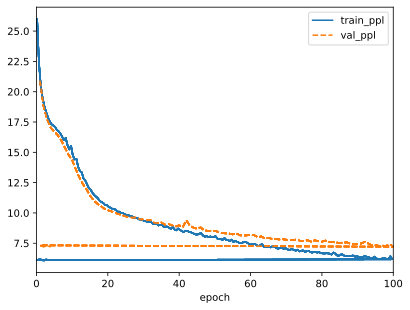

In [ ]:
trainer = d2l.Trainer(max_epochs=100, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)


In [8]:
"""GRU"""
class GRUScratch(nn.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens
        self.sigma = sigma

        # Define lambda functino for weight initialization
        # *shape unpacks arguments
        init_weight = lambda *shape: nn.Parameter(torch.randn(*shape) * sigma)
        def triple():
            return (init_weight(num_inputs, num_hiddens), # Input to hidden
                    init_weight(num_inputs, num_hiddens), # Hidden to hidden
                    nn.Parameter(torch.zeros(num_hiddens))) # Bias

        self.W_xz, self.W_hz, self.b_z = triple() # Update gate parameters
        self.W_xr, self.W_hr, self.b_r = triple() # Reset gate parameters
        self.W_xh, self.W_hh, self.b_h = triple() # Candidate hidden state parameters

In [11]:
def forward(self, inputs, H=None):
    """
        Forward pass of the network.
        :param inputs: Inputs.
        :param H: Hidden state.
    """
    # If H is None, initialize it to zeros
    # inputs.shape[1] refers to batch_size
    if H is None:
        H = torch.zeros((inputs.shape[1], self.num_hiddens), device=inputs.device)
    outputs = []
    for X in inputs:
        # H refers to H_t-1, H_tilde is a candidate hidden state
        R = torch.sigmoid(torch.matmul(X, self.W_xr) + torch.matmul(H, self.W_hr) + self.b_r)
        Z = torch.sigmoid(torch.matmul(X, self.W_xz) + torch.matmul(H, self.W_hz) + self.b_z)
        dim1 = torch.matmul(X, self.W_xh) # Debugging
        dim2 = torch.matmul(R * H, self.W_hh)
        H_tilde = torch.tanh(dim1 + dim2 + self.b_h)

        # Update H
        H = Z * H + (1 - Z) * H_tilde
        outputs.append(H)
    return outputs, H

# Add the forward method to the GRU
GRUScratch.forward = forward

In [10]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
gru = GRUScratch(num_inputs=len(data.vocab), num_hiddens=32)
model = d2l.RNNLMScratch(gru, vocab_size=len(data.vocab), lr=4)

trainer = d2l.Trainer(max_epochs=50, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1024x32 and 28x32)